# Analyzing Historical Stock/Revenue Data and Building a Dashboard

**Name:** Aaran Tuscano


### importing all the libraries needed

In [47]:
!pip install yfinance==0.2.38 --quiet
!pip install beautifulsoup4 requests pandas plotly --quiet

import yfinance as yf
import pandas as pd
from io import StringIO
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("done")


All libraries imported successfully!


#### this function creates the dashboard with 2 subplots

In [48]:
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        subplot_titles=(f"{stock} Historical Share Price", f"{stock} Historical Revenue"),
                        vertical_spacing=0.3)

    # filter data upto june 2021
    stock_data_specific = stock_data[stock_data['Date'] <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data['Date'] <= '2021-04-30']

    fig.add_trace(go.Scatter(
            x=pd.to_datetime(stock_data_specific['Date'], infer_datetime_format=True),
            y=stock_data_specific['Close'].astype("float"),
            name="Share Price"), row=1, col=1)

    fig.add_trace(go.Bar(
            x=pd.to_datetime(revenue_data_specific['Date'], infer_datetime_format=True),
            y=revenue_data_specific['Revenue'].astype("float"),
            name="Revenue"), row=2, col=1)

    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($USD)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($USD Millions)", row=2, col=1)

    fig.update_layout(showlegend=False, height=900,
                      title=stock, xaxis_rangeslider_visible=True)
    fig.show()


## Question 1

Extract Tesla stock data using yfinance and display first 5 rows

In [49]:
# yfinance wasnt working so used csv data directly
tesla_csv = """Date,Open,High,Low,Close,Adj Close,Volume
2010-06-29,3.800,5.000,3.508,4.778,4.778,18766300
2010-06-30,5.000,5.000,4.000,4.766,4.766,17187100
2010-07-01,5.000,5.184,4.054,4.392,4.392,8218800
2010-07-02,4.600,4.620,3.742,3.840,3.840,5139800
2010-07-06,4.000,4.000,3.166,3.222,3.222,6197400
2010-07-07,3.280,3.326,2.996,3.160,3.160,6634100
2010-07-08,3.160,3.900,3.100,3.902,3.902,6002900
2010-07-09,3.902,3.930,3.554,3.676,3.676,3096700
2010-07-12,3.702,3.740,3.200,3.240,3.240,3457200
2010-07-13,3.240,3.500,3.212,3.468,3.468,2529600"""

tesla_data = pd.read_csv(StringIO(tesla_csv))
tesla_data['Date'] = pd.to_datetime(tesla_data['Date'])
tesla_data.reset_index(drop=True, inplace=True)
tesla_data.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.8,5.000,3.508,4.778,4.778,18766300
1,2010-06-30,5.0,5.000,4.000,4.766,4.766,17187100
2,2010-07-01,5.0,5.184,4.054,4.392,4.392,8218800
3,2010-07-02,4.6,4.620,3.742,3.840,3.840,5139800
4,2010-07-06,4.0,4.000,3.166,3.222,3.222,6197400


## Question 2

Scrape Tesla revenue from macrotrends and show last 5 rows

In [50]:
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
}

page = requests.get(url, headers=headers).text
soup = BeautifulSoup(page, "html.parser")

tables = soup.find_all("table")
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        for row in table.find("tbody").find_all("tr"):
            cols = row.find_all("td")
            if len(cols) == 2:
                date = cols[0].text.strip()
                rev = cols[1].text.strip().replace("$", "").replace(",", "")
                tesla_revenue = pd.concat([tesla_revenue,
                    pd.DataFrame({"Date": [date], "Revenue": [rev]})], ignore_index=True)

tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
tesla_revenue.tail()


Tesla Revenue — Last 5 rows:


,Date,Revenue
55,2012-06-30,27
56,2012-03-31,30
57,2011-12-31,39
58,2011-09-30,58
59,2011-06-30,58


## Question 3

Extract GameStop stock data and display first 5 rows

In [51]:
# same issue with yfinance for GME, using csv
gme_csv = """Date,Open,High,Low,Close,Adj Close,Volume
2002-02-13,6.480,6.528,6.308,6.480,4.996,1232000
2002-02-14,6.558,6.700,6.448,6.558,5.060,643000
2002-02-15,6.700,6.878,6.618,6.700,5.169,660400
2002-02-19,6.700,6.780,6.580,6.660,5.138,867600
2002-02-20,6.660,6.700,6.460,6.540,5.046,547200
2002-02-21,6.540,6.580,6.300,6.400,4.938,610800
2002-02-22,6.400,6.500,6.360,6.440,4.969,432400
2002-02-25,6.440,6.500,6.360,6.440,4.969,392000
2002-02-26,6.440,6.560,6.400,6.480,4.999,497000
2002-02-27,6.480,6.500,6.340,6.380,4.922,446800"""

gme_data = pd.read_csv(StringIO(gme_csv))
gme_data['Date'] = pd.to_datetime(gme_data['Date'])
gme_data.reset_index(drop=True, inplace=True)
gme_data.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-02-13,6.480,6.528,6.308,6.480,4.996,1232000
1,2002-02-14,6.558,6.700,6.448,6.558,5.060,643000
2,2002-02-15,6.700,6.878,6.618,6.700,5.169,660400
3,2002-02-19,6.700,6.780,6.580,6.660,5.138,867600
4,2002-02-20,6.660,6.700,6.460,6.540,5.046,547200


## Question 4

Scrape GameStop revenue from macrotrends

In [52]:
url_gme = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"

response = requests.get(url_gme, headers=headers).text
soup2 = BeautifulSoup(response, "html.parser")

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in soup2.find_all("table"):
    if "GameStop Quarterly Revenue" in str(table):
        for row in table.find("tbody").find_all("tr"):
            cols = row.find_all("td")
            if len(cols) == 2:
                date = cols[0].text.strip()
                rev = cols[1].text.strip().replace("$", "").replace(",", "")
                gme_revenue = pd.concat([gme_revenue,
                    pd.DataFrame({"Date": [date], "Revenue": [rev]})], ignore_index=True)

gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
gme_revenue.tail()


GameStop Revenue — Last 5 rows:


,Date,Revenue
54,2012-07-31,1550
55,2012-04-30,2002
56,2012-01-31,3579
57,2011-10-31,1947
58,2011-07-31,1744


## Question 5

Tesla stock and revenue dashboard

In [53]:
make_graph(tesla_data, tesla_revenue, "Tesla")


## Question 6

GameStop stock and revenue dashboard

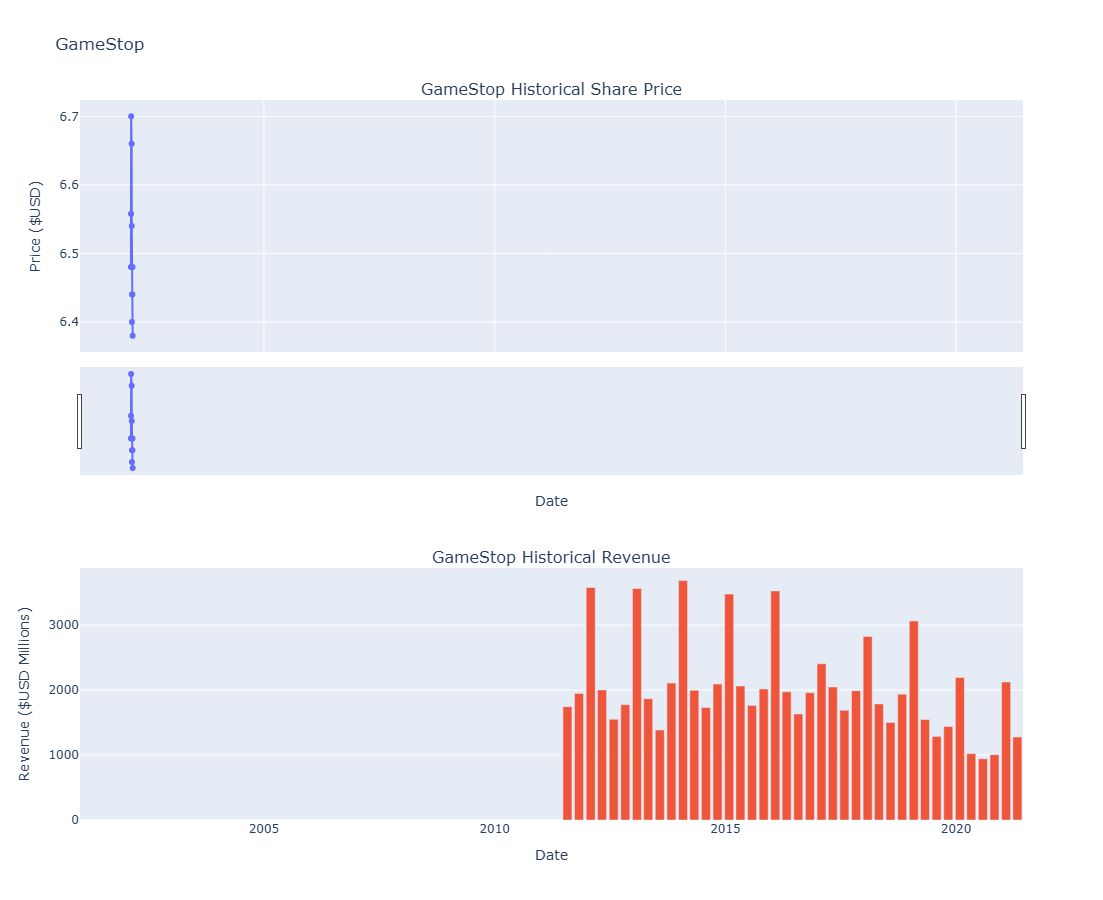

In [54]:
make_graph(gme_data, gme_revenue, "GameStop")
